# **MediaPipePose 3D Keypoints Stereo Triangulation**

## **Pipeline**
* Use MediaPipePose to get 2D keypoints (pixel coordinates) of stereo images
* Triangulate the pair of 2D keypoints (camera coordinates)
* Convert 3D keypoints to Unreal Engine camera coordinates
* Render pose visualization
* Compute output vectors

### **Setup**

```
conda create -n fbv-media-pipe-pose python=3.10
conda activate fbv-media-pipe-pose
pip install mediapipe opencv-python
pip install ipympl
conda install ipykernel=6.29.5
```

In [57]:
import cv2
import numpy as np
import time

In [58]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision

In [59]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [60]:
%matplotlib widget

In [61]:
IMAGE_A_PATH = "../../../dataset/images_A/00101A.png"
IMAGE_B_PATH = "../../../dataset/images_B/00101B.png"
MODEL_PATH = "../../models/pose_landmarker_full.task"

FOCAL_LENGTH_MM = 35.0
SENSOR_WIDTH_MM = 36.0 
BASELINE_M = 0.1

### **Sample Images**

Image Shape: (1080, 1920, 3)


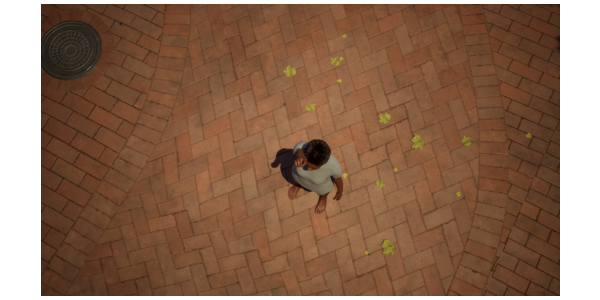

In [62]:
# Load & Preview Sample Image
image_A = cv2.imread(IMAGE_A_PATH)
image_A = cv2.cvtColor(image_A, cv2.COLOR_BGR2RGB)
print(f"Image Shape: {image_A.shape}")

fig = plt.figure(figsize=(6, 3), layout="constrained")
plt.imshow(image_A)
plt.axis('off')
plt.show()

Image Shape: (1080, 1920, 3)


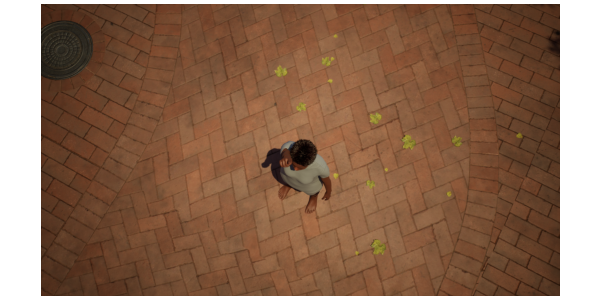

In [63]:
# Load & Preview Sample Image
image_B = cv2.imread(IMAGE_B_PATH)
image_B = cv2.cvtColor(image_B, cv2.COLOR_BGR2RGB)
print(f"Image Shape: {image_B.shape}")

fig = plt.figure(figsize=(6, 3), layout="constrained")
plt.imshow(image_B)
plt.axis('off')
plt.show()

### **Keypoint Regression (CPU)**

In [64]:
# Create PoseLandmarker Object

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(base_options=base_options)
detector = vision.PoseLandmarker.create_from_options(options)

In [65]:
# Detect Keypoints

start_time = time.perf_counter()

mp_image_A = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_A)
mp_image_B = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_B)

detection_result_A = detector.detect(mp_image_A)
detection_result_B = detector.detect(mp_image_B)

end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Detection took: {execution_time:.4f} seconds")
print(f"FPS: {1/execution_time:.2f}")

Detection took: 0.0420 seconds
FPS: 23.83


In [66]:
# Helper Util from: https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker
def draw_landmarks_on_image(rgb_image, detection_result):
    pose_landmarks_list = detection_result.pose_landmarks
    annotated_image = np.copy(rgb_image)

    pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
    pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

    for pose_landmarks in pose_landmarks_list:
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=pose_landmarks,
            connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
            landmark_drawing_spec=pose_landmark_style,
            connection_drawing_spec=pose_connection_style)

    return annotated_image

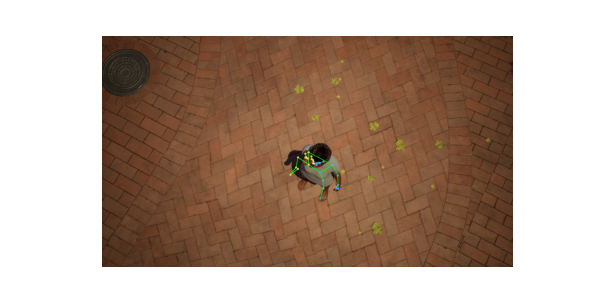

In [67]:
# Show Annotated Image A (Pixel Coordinates)

annotated_image = draw_landmarks_on_image(mp_image_A.numpy_view(), detection_result_A)
plt.figure(figsize=(6, 3))
plt.imshow(annotated_image)
plt.axis('off')
plt.show()

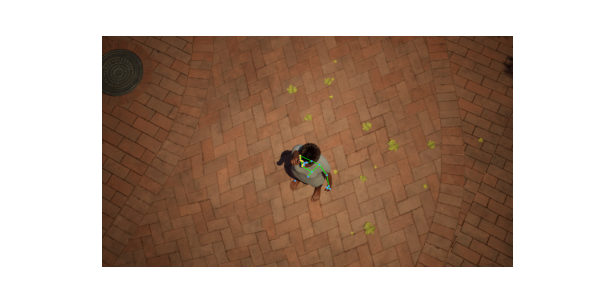

In [68]:
# Show Annotated Image B (Pixel Coordinates)

annotated_image = draw_landmarks_on_image(mp_image_B.numpy_view(), detection_result_B)
plt.figure(figsize=(6, 3))
plt.imshow(annotated_image)
plt.axis('off')
plt.show()

In [69]:
# Helper Util from: https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker
def draw_landmarks_on_image(rgb_image, detection_result, other):
    pose_landmarks_list = detection_result.pose_landmarks
    annotated_image = np.copy(rgb_image)

    pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
    pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

    for pose_landmarks in pose_landmarks_list:
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=pose_landmarks,
            connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
            landmark_drawing_spec=pose_landmark_style,
            connection_drawing_spec=pose_connection_style)

    pose_landmarks_list = other.pose_landmarks

    pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
    pose_connection_style = drawing_utils.DrawingSpec(color=(255, 0, 0), thickness=2)

    for pose_landmarks in pose_landmarks_list:
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=pose_landmarks,
            connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
            landmark_drawing_spec=pose_landmark_style,
            connection_drawing_spec=pose_connection_style)

    return annotated_image

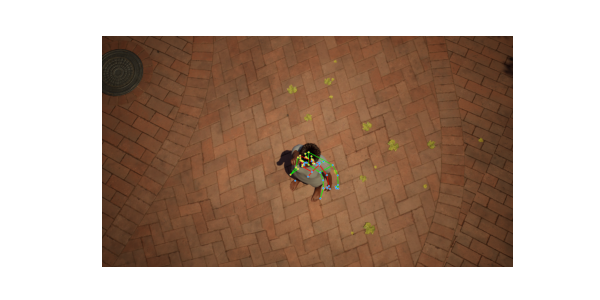

In [70]:
# Show Annotated Image B (Pixel Coordinates)

annotated_image = draw_landmarks_on_image(mp_image_B.numpy_view(), detection_result_A, detection_result_B)
plt.figure(figsize=(6, 3))
plt.imshow(annotated_image)
plt.axis('off')
plt.show()

### **Confidence Filter & Convert To Numpy**

In [71]:
# Remove Low Confidence Keypoints

def extract_keypoints_with_confidence(detection_result, vis_thresh=0.6, pres_thresh=0.6):
    if not detection_result.pose_landmarks:
        return None, None

    landmarks = detection_result.pose_landmarks[0]

    keypoints = []
    mask = []

    body_indices = list(range(11, 17)) + list(range(23, 33))
    body_indices = list(range(0, 33))

    for i in body_indices:
        lm = landmarks[i]
        valid = (lm.visibility > vis_thresh) and (lm.presence > pres_thresh)
        
        keypoints.append([lm.x, lm.y])
        mask.append(valid)

    return np.array(keypoints), np.array(mask)

kpts_A, mask_A = extract_keypoints_with_confidence(detection_result_A)
kpts_B, mask_B = extract_keypoints_with_confidence(detection_result_B)

valid_mask = mask_A & mask_B

force_indices = [12, 16] 
valid_mask[force_indices] = True

keypoints_2d_A = kpts_A.copy()
keypoints_2d_B = kpts_B.copy()

keypoints_2d_A[~valid_mask] = np.nan
keypoints_2d_B[~valid_mask] = np.nan

### **Triangulate Keypoints**

In [72]:
def triangulate_keypoints_cv(kpts_A, kpts_B, img_shape, focal_mm, sensor_w_mm, baseline_m):
    h, w = img_shape[:2]

    kpts_A_px = kpts_A * np.array([w, h])
    kpts_B_px = kpts_B * np.array([w, h])

    f_px = (focal_mm * w) / sensor_w_mm
    cx, cy = w / 2, h / 2

    K = np.array([
        [f_px, 0, cx],
        [0, f_px, cy],
        [0, 0, 1]
    ])

    R = np.eye(3)
    T = np.array([baseline_m, 0, 0])

    P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))
    P2 = K @ np.hstack((R, T.reshape(3, 1)))

    valid = ~np.isnan(kpts_A_px[:, 0]) & ~np.isnan(kpts_B_px[:, 0])

    pts1 = kpts_A_px[valid].T
    pts2 = kpts_B_px[valid].T

    points_4d = cv2.triangulatePoints(P1, P2, pts1, pts2)
    points_3d_valid = (points_4d[:3] / points_4d[3]).T

    points_3d = np.full((kpts_A.shape[0], 3), np.nan)
    points_3d[valid] = points_3d_valid

    return points_3d

In [73]:
transformed_keypoints_3d = triangulate_keypoints_cv(
    keypoints_2d_A,
    keypoints_2d_B,
    image_A.shape,
    FOCAL_LENGTH_MM,
    SENSOR_WIDTH_MM,
    -BASELINE_M
)
print("Z values:\n", transformed_keypoints_3d[:, 2])

Z values:
 [3.76055171 3.31751084 3.12363182 3.04732385 3.71053441 3.57773787
 3.56657082 3.41022725 3.57813634 3.25914263 3.76275436 3.0247995
 4.64533618 3.71956654        nan 4.27614542 3.55608974 4.7711964
        nan 4.59071883        nan 4.56191359        nan 4.7595373
 6.30389155 2.63683076        nan        nan        nan        nan
        nan        nan        nan]


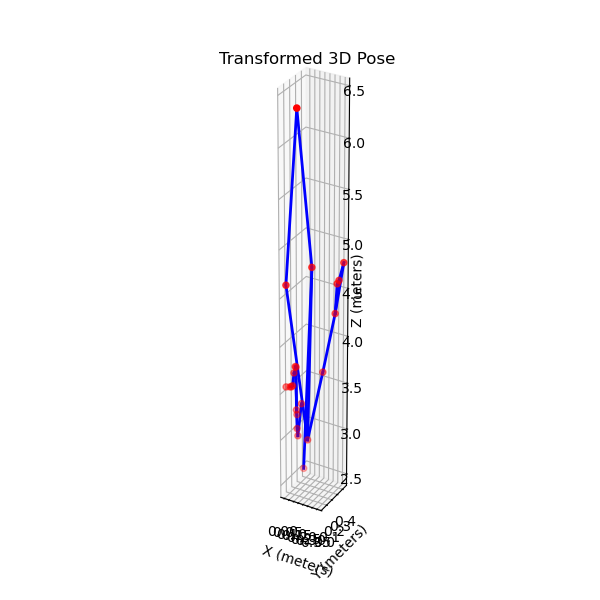

In [74]:
# Visualize Transformed 3D Keypoints

def plot_pose_3d(points_3d):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], c='r', marker='o')

    for connection in vision.PoseLandmarksConnections.POSE_LANDMARKS:
        start_idx, end_idx = connection.start, connection.end
        if start_idx < len(points_3d) and end_idx < len(points_3d):
            xs = [points_3d[start_idx, 0], points_3d[end_idx, 0]]
            ys = [points_3d[start_idx, 1], points_3d[end_idx, 1]]
            zs = [points_3d[start_idx, 2], points_3d[end_idx, 2]]
            ax.plot(xs, ys, zs, c='b', linewidth=2)

    ax.set_aspect('equal')
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_zlabel('Z (meters)')
    ax.set_title('Transformed 3D Pose')
    
    plt.show()

plot_pose_3d(transformed_keypoints_3d)

### **Convert To Unreal Engine Coordinates**

In [75]:
# Apply Coordinate Conversion

def convert_to_unreal_coords(points_3d_meters):
    unreal_pts = np.zeros_like(points_3d_meters)
    
    # UE X (Forward) = CV Z
    unreal_pts[:, 0] = points_3d_meters[:, 2] * 100
    
    # UE Y (Right) = CV X
    unreal_pts[:, 1] = points_3d_meters[:, 0] * 100
    
    # UE Z (Up) = -CV Y
    unreal_pts[:, 2] = -points_3d_meters[:, 1] * 100
    
    return unreal_pts

ue_keypoints_3d = convert_to_unreal_coords(transformed_keypoints_3d)

C:\Users\ExoHorizon\AppData\Local\Temp\ipykernel_35888\1473797955.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(8, 8))


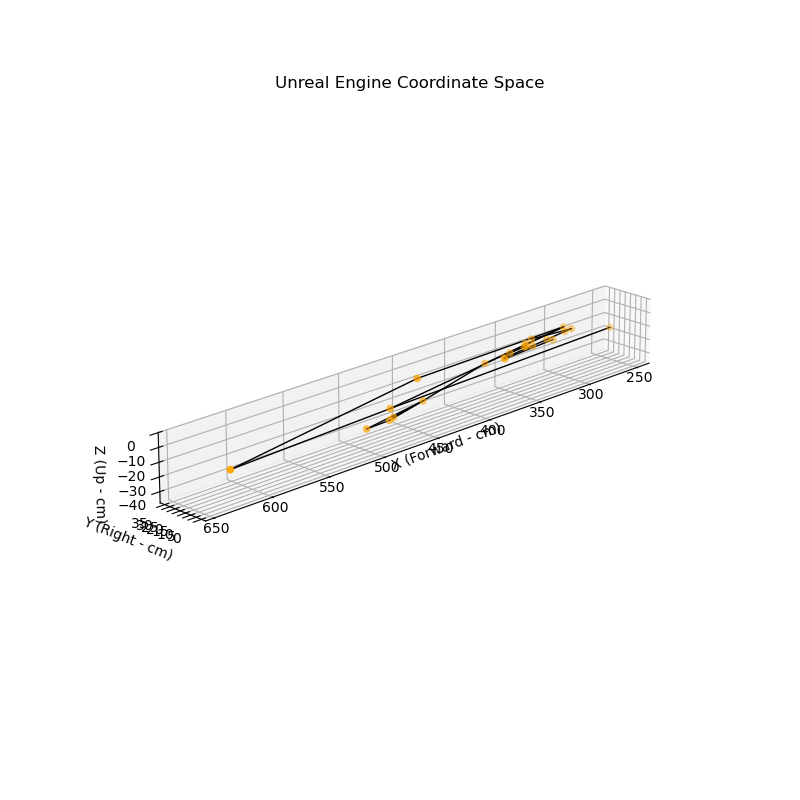

In [76]:
# Verify Coordinate Conversion

def plot_pose_unreal_3d(points_3d):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], c='orange', marker='o')

    for connection in vision.PoseLandmarksConnections.POSE_LANDMARKS:
        start_idx, end_idx = connection.start, connection.end
        if start_idx < len(points_3d) and end_idx < len(points_3d):
            xs = [points_3d[start_idx, 0], points_3d[end_idx, 0]]
            ys = [points_3d[start_idx, 1], points_3d[end_idx, 1]]
            zs = [points_3d[start_idx, 2], points_3d[end_idx, 2]]
            ax.plot(xs, ys, zs, c='black', linewidth=1)

    ax.set_xlabel('X (Forward - cm)')
    ax.set_ylabel('Y (Right - cm)')
    ax.set_zlabel('Z (Up - cm)')
    ax.set_title('Unreal Engine Coordinate Space')

    ax.set_aspect('equal')
    ax.invert_yaxis()
    
    ax.view_init(elev=20, azim=45)
    
    plt.show()

plot_pose_unreal_3d(ue_keypoints_3d)

### **Compute Output Vector**

In [77]:
# Given Constants

camera_coords = np.array([0, 0, 0])
world_up = np.array([0, 0, 1])
camera_pitch_rad = np.deg2rad(-76.16348683834077)

In [78]:
# Get Right Shoulder & Wrist Coordinates

shoulder_coords = ue_keypoints_3d[12]
wrist_coords = ue_keypoints_3d[16]

print(shoulder_coords)
print(wrist_coords)

[464.53361846   1.29991523  -2.86532594]
[355.60897396  -1.1985384   -6.23868481]


In [79]:
# Shoulder-Camera Distance

distance = np.linalg.norm(shoulder_coords)
print(distance, "cm")

464.54427405121737 cm


In [80]:
# Shoulder-Wrist Shoulder-Camera Vectors

shoulder_wrist = wrist_coords - shoulder_coords
shoulder_wrist /= np.linalg.norm(shoulder_wrist)

shoulder_camera = camera_coords - shoulder_coords
shoulder_camera /= np.linalg.norm(shoulder_camera)

print(shoulder_wrist)
print(shoulder_camera)

[-0.9992582  -0.02292044 -0.03094668]
[-0.99997706 -0.00279826  0.00616804]


In [81]:
# Angular Separation

angular_separation_rad = np.arccos(np.clip(np.dot(shoulder_wrist, shoulder_camera), -1.0, 1.0))
angular_separation_deg = np.rad2deg(angular_separation_rad)

print(angular_separation_deg, "deg")


2.4194740790966303 deg


In [82]:
# Camera Un-Pitch Matrix (Aligns Z-Axis with Gravity)

c, s = np.cos(-camera_pitch_rad), np.sin(-camera_pitch_rad)
unpitch_matrix = np.array([
    [c,  0, s],
    [0,  1, 0],
    [-s, 0, c]
])
print(unpitch_matrix)

[[ 0.23915229  0.          0.97098207]
 [ 0.          1.          0.        ]
 [-0.97098207  0.          0.23915229]]


In [83]:
# Un-Pitch Vectors

shoulder_wrist_gravity = unpitch_matrix @ shoulder_wrist
shoulder_wrist_gravity /= np.linalg.norm(shoulder_wrist_gravity)

shoulder_camera_gravity = unpitch_matrix @ shoulder_camera
shoulder_camera_gravity /= np.linalg.norm(shoulder_camera_gravity)

print(shoulder_wrist_gravity)
print(shoulder_camera_gravity)

[-0.26902356 -0.02292044  0.96286083]
[-0.23315775 -0.00279826  0.9724349 ]


In [84]:
# Yaw & Pitch Components

shoulder_wrist_gravity_yaw = np.rad2deg(np.atan2(shoulder_wrist_gravity[1], shoulder_wrist_gravity[0]))
shoulder_wrist_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_wrist_gravity[-1], -1.0, 1.0)))

shoulder_camera_gravity_yaw = np.rad2deg(np.atan2(shoulder_camera_gravity[1], shoulder_camera_gravity[0]))
shoulder_camera_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_camera_gravity[-1], -1.0, 1.0)))

delta_yaw = (shoulder_wrist_gravity_yaw - shoulder_camera_gravity_yaw + 180) % 360 - 180
delta_pitch = shoulder_wrist_gravity_pitch - shoulder_camera_gravity_pitch

print(delta_yaw)
print(delta_pitch)

4.182154744502782
-2.180116540140716
